# **Biodiversity Report - ACUS Zamora Chinchipe**

Author: Daning Montaño - Ocampo

Kernel: R

Biodiversity report based on database records

# **1. Packages and libraries**

In [ ]:
suppressMessages({
  library(dplyr)
  library(readr)
  library(bdc) ## data cleaning
  library(lubridate)
  library(sf)
  library(ggplot2)
  library(openxlsx)
  library(ggimage)
  library(ggplot2)
  library(dplyr)
  library(ggforce)
  library(scales)
  library(tibble)


  source("../functions/themes_nci_zch.R")})

Warning messages:
1: package ‘dplyr’ was built under R version 4.3.3 
2: package ‘readr’ was built under R version 4.3.3 
3: package ‘lubridate’ was built under R version 4.3.3 
4: package ‘ggimage’ was built under R version 4.3.3 
5: package ‘ggforce’ was built under R version 4.3.2 


# **2. Load data**

In [ ]:
suppressMessages({
bio_records = read.csv( "../../../DATOS/Datasets/Biodiversidad/biodiversidad_ocurrences_clean.csv")#|>
 # filter(coordinateUncertaintyInMeters <= 5000 | is.na(coordinateUncertaintyInMeters))

 grids_1km_buffer = st_read("../../../DATOS/SHP/Grids/grid_zamora_ch_buffer_1km.shp")

# Zamora Ch

zamora_ch = st_read("../../../DATOS/SHP/Limites_politicos/Provincia_ZCh.shp")

# ACUS
acus_area = st_read("../../../DATOS/SHP/ACUS/ACUS_ZCH_fix.shp")


## IUCN data (global-local)

iucn = read.xlsx("../../../DATOS/Datasets/Biodiversidad/tabla_biodiversidad_ecuador_redlists_all_gbif.xlsx")|>
  select(Estado_conservacion, Endemica, sci_name_gbif)|>
  mutate(scientificName = sci_name_gbif )|>
  select(-sci_name_gbif)
})

Reading layer `grid_zamora_ch_buffer_1km' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Grids\grid_zamora_ch_buffer_1km.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 15779 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 794083.7 ymax: 9631351
Projected CRS: WGS 84 / UTM zone 17S
Reading layer `Provincia_ZCh' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Limites_politicos\Provincia_ZCh.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1 feature and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 674165.2 ymin: 9445216 xmax: 792756.4 ymax: 9630431
Projected CRS: WGS 84 / UTM zone 17S
Reading layer `ACUS_ZCH_fix' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\ACUS\ACUS_ZCH_fix.shp' using driver `ESRI Shapefile'
Simple feature collection with 4 features and 2 fields
Geometry type:

# **3. Merge with IUCN data**

In [80]:
bio_records_iucn = bio_records |>
  left_join(iucn,  by = c("scientificName"))

Warning message:
In left_join(bio_records, iucn, by = c("scientificName")) :
  Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1449 of `x` matches multiple rows in `y`.
ℹ Row 7486 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning.


# **4. Merge data**

In [81]:
# Transform to sf object
bio_records_sf = st_as_sf(
  bio_records_iucn,
  coords = c("decimalLongitude", "decimalLatitude"),
  crs = 4326
) |>
  st_transform(32717)

## **4.1 Zamora Ch.**

In [82]:
recors_zamora_ch <- st_join(
  bio_records_sf,
  zamora_ch %>% select( DPA_DESPRO ),   
  join = st_within                              # inside polygons
)

## **4.2 ACUS**

In [8]:
recors_acus <- st_join(
  bio_records_sf,
  acus_area %>% select( Nombre ),   
  join = st_within                              # inside polygons
)


## **4.3 GRID IDs**

In [43]:
# Join and Filtering Logic
records_grids_id <- st_join(
  bio_records_sf,
  grids_1km_buffer %>% select(id),   
  join = st_within
) 

## **4.4 Join data**

In [92]:

# 1. Crear tabla de nombres sin duplicados por database_id
# Si un mismo database_id aparece varias veces, se conserva solo un Nombre
acus_names <- recors_acus %>%
  st_drop_geometry() %>% 
  distinct(database_id, Nombre) %>% 
  group_by(database_id) %>%
  summarise(
    Nombre = first(Nombre),
    .groups = "drop"
  )

# 2. Preparar base principal
all_data_bio <- bio_records_sf %>%
  mutate(
    grid_id   = records_grids_id$id,
    Provincia = recors_zamora_ch$DPA_DESPRO
  ) %>%
  st_drop_geometry() %>%
  left_join(acus_names, by = "database_id")

all_data_bio <- all_data_bio %>%
 # filter(!is.na(Nombre))%>%
  as.data.frame() %>%
  dplyr::filter(
    (kingdom == "Animalia" & class %in% c("Amphibia","Aves","Mammalia","Reptilia","Squamata")) |
    (kingdom == "Plantae")
  ) %>%
  dplyr::mutate(
    Group = dplyr::case_when(
      kingdom == "Plantae" ~ "Plantas",
      class %in% c("Reptilia","Squamata") ~ "Reptiles",
      class == "Amphibia" ~ "Anfibios",
      class == "Aves" ~ "Aves",
      class == "Mammalia" ~ "Mamíferos",
      TRUE ~ NA_character_
    )
  )

# 3. Opcional: verificar si aún quedaron duplicados por database_id
duplicados_id <- all_data_bio %>%
  count(database_id) %>%
  filter(n > 1)

head(all_data_bio)

  database_id            scientificName       occurrenceID  eventDate  kingdom
1 BIOWEB_1207      Pristimantis minimus QCAZA41668_SC28035 2009-04-12 Animalia
2 BIOWEB_1256   Pristimantis nangaritza QCAZA41728_SC28166 2009-04-19 Animalia
3 BIOWEB_1277 Pristimantis andinognomus QCAZA45553_SC29125 2009-09-19 Animalia
4 BIOWEB_1483    Pristimantis exoristus  QCAZA55473_EOC007 2013-01-23 Animalia
5 BIOWEB_1558 Pristimantis citriogaster QCAZA57130_SC46568 2014-04-12 Animalia
6 BIOWEB_1574  Pristimantis cryptomelas QCAZA57146_SC46606 2014-04-13 Animalia
    phylum    class order        genus specificEpithet collectionID
1 Chordata Amphibia Anura Pristimantis         minimus         <NA>
2 Chordata Amphibia Anura Pristimantis      nangaritza         <NA>
3 Chordata Amphibia Anura Pristimantis    andinognomus         <NA>
4 Chordata Amphibia Anura Pristimantis       exoristus         <NA>
5 Chordata Amphibia Anura Pristimantis    citriogaster         <NA>
6 Chordata Amphibia Anura Pristimantis 

In [94]:
write.csv(all_data_bio, "../../../DATOS/Datasets/Biodiversidad/biodiversidad_all_data.csv")

In [2]:
bio_records_complt = read.csv( "../../../DATOS/Datasets/Biodiversidad/biodiversidad_all_data.csv")

# **5. Report**

## **5.1 Zamora Ch**

In [114]:
recors_zamora_ch_filter <- bio_records_complt %>%
  filter(Provincia == "ZAMORA CHINCHIPE") %>%
 # filter(!is.na(Nombre))%>%
  as.data.frame() %>%
  dplyr::filter(
    (kingdom == "Animalia" & class %in% c("Amphibia","Aves","Mammalia","Reptilia","Squamata")) |
    (kingdom == "Plantae")
  ) %>%
  dplyr::mutate(
    Group = dplyr::case_when(
      kingdom == "Plantae" ~ "Plantas",
      class %in% c("Reptilia","Squamata") ~ "Reptiles",
      class == "Amphibia" ~ "Anfibios",
      class == "Aves" ~ "Aves",
      class == "Mammalia" ~ "Mamíferos",
      TRUE ~ NA_character_
    )
  )

head(recors_zamora_ch_filter)

  X database_id            scientificName       occurrenceID  eventDate  kingdom   phylum    class order
1 1 BIOWEB_1207      Pristimantis minimus QCAZA41668_SC28035 2009-04-12 Animalia Chordata Amphibia Anura
2 2 BIOWEB_1256   Pristimantis nangaritza QCAZA41728_SC28166 2009-04-19 Animalia Chordata Amphibia Anura
3 3 BIOWEB_1277 Pristimantis andinognomus QCAZA45553_SC29125 2009-09-19 Animalia Chordata Amphibia Anura
4 4 BIOWEB_1483    Pristimantis exoristus  QCAZA55473_EOC007 2013-01-23 Animalia Chordata Amphibia Anura
5 5 BIOWEB_1558 Pristimantis citriogaster QCAZA57130_SC46568 2014-04-12 Animalia Chordata Amphibia Anura
6 6 BIOWEB_1574  Pristimantis cryptomelas QCAZA57146_SC46606 2014-04-13 Animalia Chordata Amphibia Anura
         genus specificEpithet collectionID institutionCode collectionCode ownerInstitutionCode basisOfRecord
1 Pristimantis         minimus         <NA>            <NA>           <NA>                 <NA>          <NA>
2 Pristimantis      nangaritza         <NA>  

### Summary

In [115]:
n_sp = length(unique(recors_zamora_ch_filter$scientificName))
n_records = length(recors_zamora_ch_filter$scientificName)
ratio_sp_records = round(n_records/n_sp,0)
cat("Dentro de Zamora Ch. existen un total de: ", n_records, " registros y: ",n_sp, " especies. Por cada especie existen en aproximandame: ", ratio_sp_records)

Dentro de Zamora Ch. existen un total de:  483765  registros y:  8889  especies. Por cada especie existen en aproximandame:  54

### Records by group

In [116]:
records_by_group_zch = recors_zamora_ch_filter %>%
  group_by(Group)%>%
  summarise(Total_records = n())%>%
  arrange(-Total_records)
records_by_group_zch

# A tibble: 5 × 2
  Group     Total_records
  <chr>             <int>
1 Aves             407728
2 Plantas           63814
3 Anfibios           5429
4 Mamíferos          4879
5 Reptiles           1915

In [117]:
icons_plots = c("../Icons/Aves.png", "../Icons/Plantas.png", "../Icons/mamiferos.png", "../Icons/anfibios.png", "../Icons/reptiles.png")
records_by_group_zch$Incons = icons_plots

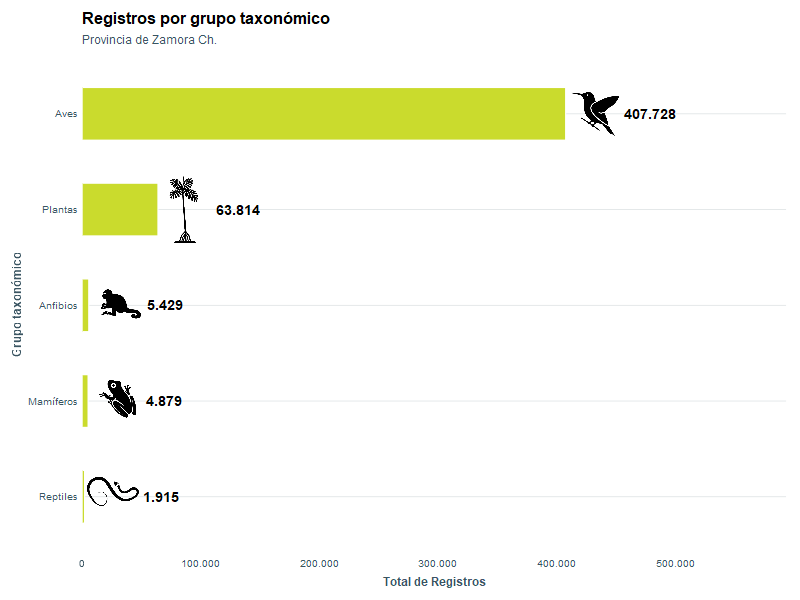

In [118]:
# 1. Calcular un margen dinámico basado en el valor máximo de tus datos
# Esto asegura que la separación sea proporcional al gráfico
max_val <- max(records_by_group_zch$Total_records, na.rm = TRUE)
offset_etiqueta <- max_val * 0.12  # 12% del máximo para el texto
offset_imagen <- max_val * 0.06    # 5% del máximo para el icono

# 2. Crear el gráfico
plot_records_group_zch <- ggplot(records_by_group_zch, aes(x = reorder(Group, Total_records), y = Total_records)) +
  # Barras
  geom_bar(stat = "identity", width = 0.55, fill = pal_zch["verde_lima"], color = "white") +
  
  # IMAGEN: Usamos posición dinámica en 'y' en lugar de nudge fijo
  geom_image(
    aes(y = Total_records + offset_imagen, image = icons_plots),
    size = 0.11, # Ajustado ligeramente para que no sature
    by = "width"
  ) +
  
  # ETIQUETAS: Posición dinámica para que siempre estén a la derecha de la imagen
  geom_text(
    aes(
      y = Total_records + offset_etiqueta, 
      label = scales::number(Total_records, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,                   # Alineado a la izquierda desde el punto de inserción
    color = "black",
    fontface = "bold",
    size = 5
  ) +
  
  coord_flip() +
  
  # ESCALA Y: Aumentamos el 'expand' para dar espacio a la derecha
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.3)) # 30% de espacio extra a la derecha
  ) +
  
  labs(
    title = "Registros por grupo taxonómico",
    x = "Grupo taxonómico",
    y = "Total de Registros",
    subtitle = "Provincia de Zamora Ch.",
  ) +
  
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none"
  )

# Visualizar
plot_records_group_zch

In [119]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Report_ocurrences/Records_ZCH.png", 
  plot = plot_records_group_zch, 
  device = "png",
  width = 165,               # Ancho en mm
  height = 130,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### Species by group

In [120]:
sp_by_group_zch = recors_zamora_ch_filter %>%
  group_by(Group)%>%
  distinct(scientificName)%>%
  summarise(Total_sp = n())%>%
  arrange(-Total_sp)
sp_by_group_zch

# A tibble: 5 × 2
  Group     Total_sp
  <chr>        <int>
1 Plantas       7387
2 Aves          1036
3 Anfibios       195
4 Mamíferos      150
5 Reptiles       121

In [121]:
icons_plots = c("../Icons/Plantas.png", "../Icons/Aves.png", "../Icons/anfibios.png", "../Icons/mamiferos.png", "../Icons/reptiles.png")
sp_by_group_zch$Incons = icons_plots

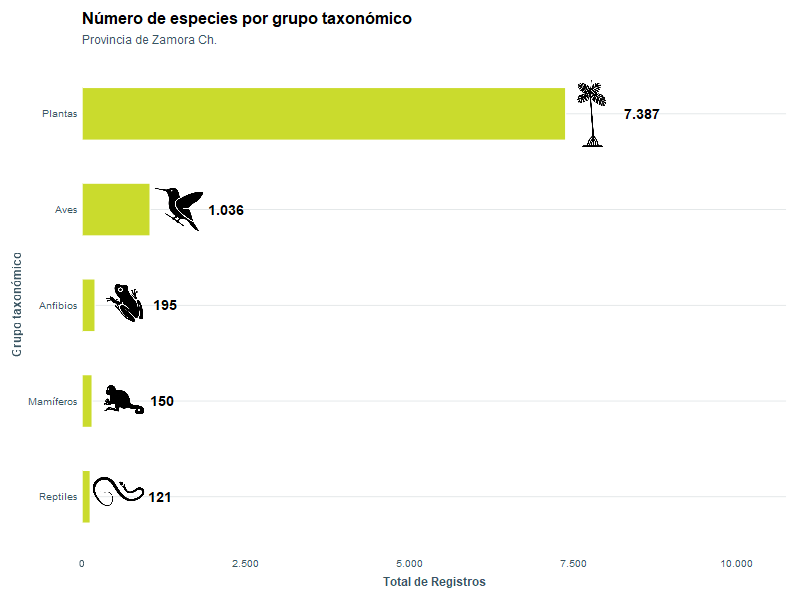

In [122]:
# 1. Calcular un margen dinámico basado en el valor máximo de tus datos
# Esto asegura que la separación sea proporcional al gráfico
max_val <- max(sp_by_group_zch$Total_sp, na.rm = TRUE)
offset_etiqueta <- max_val * 0.12  # 12% del máximo para el texto
offset_imagen <- max_val * 0.06    # 5% del máximo para el icono

# 2. Crear el gráfico
plot_sp_group_zch <- ggplot(sp_by_group_zch, aes(x = reorder(Group, Total_sp), y = Total_sp)) +
  # Barras
  geom_bar(stat = "identity", width = 0.55, fill = pal_zch["verde_lima"], color = "white") +
  
  # IMAGEN: Usamos posición dinámica en 'y' en lugar de nudge fijo
  geom_image(
    aes(y = Total_sp + offset_imagen, image = icons_plots),
    size = 0.11, # Ajustado ligeramente para que no sature
    by = "width"
  ) +
  
  # ETIQUETAS: Posición dinámica para que siempre estén a la derecha de la imagen
  geom_text(
    aes(
      y = Total_sp + offset_etiqueta, 
      label = scales::number(Total_sp, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,                   # Alineado a la izquierda desde el punto de inserción
    color = "black",
    fontface = "bold",
    size = 5
  ) +
  
  coord_flip() +
  
  # ESCALA Y: Aumentamos el 'expand' para dar espacio a la derecha
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.3)) # 30% de espacio extra a la derecha
  ) +
  
  labs(
    title = "Número de especies por grupo taxonómico",
    x = "Grupo taxonómico",
    y = "Total de Registros",
    subtitle = "Provincia de Zamora Ch."
  ) +
  
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none"
  )

# Visualizar
plot_sp_group_zch

In [123]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Report_ocurrences/Sp_ZCH.png", 
  plot = plot_sp_group_zch, 
  device = "png",
  width = 165,               # Ancho en mm
  height = 130,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### Red list

In [124]:
sp_by_group_redlist_zch = recors_zamora_ch_filter %>%
  #filter(!is.na(Estado_conservacion))%>%
  filter(Estado_conservacion %in% c("VU" ,"EN" , "CR"))%>%
  group_by(Group,Estado_conservacion)%>%
  distinct(scientificName)%>%
  summarise(Total_sp = n())
sp_by_group_redlist_zch

`summarise()` has grouped output by 'Group'. You can override using the `.groups` argument.


# A tibble: 14 × 3
# Groups:   Group [5]
   Group     Estado_conservacion Total_sp
   <chr>     <chr>                  <int>
 1 Anfibios  CR                         8
 2 Anfibios  EN                        31
 3 Anfibios  VU                        38
 4 Aves      CR                         3
 5 Aves      EN                        16
 6 Aves      VU                        35
 7 Mamíferos CR                         1
 8 Mamíferos EN                         9
 9 Mamíferos VU                        12
10 Plantas   CR                        26
11 Plantas   EN                       179
12 Plantas   VU                       414
13 Reptiles  EN                         2
14 Reptiles  VU                         4

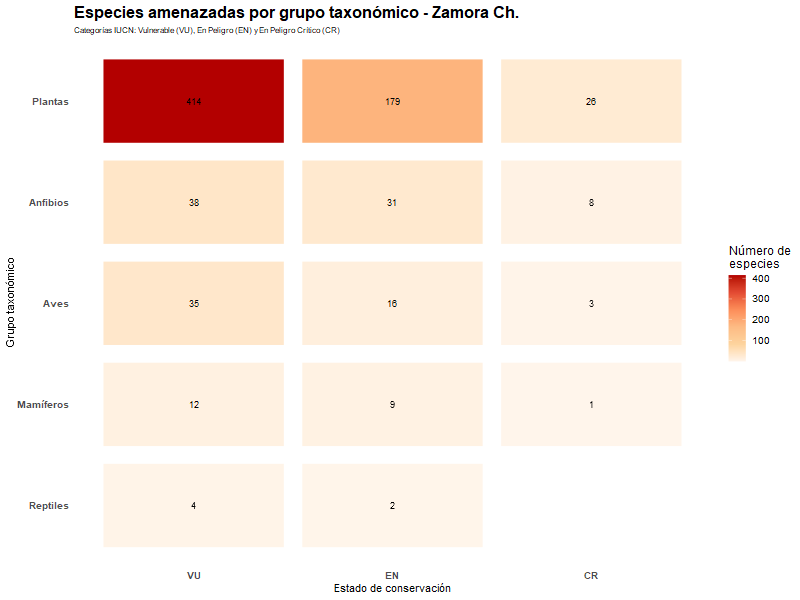

In [125]:


# =========================================================
# 1. Ordenar grupos por total de especies amenazadas
# =========================================================
orden_grupos <- sp_by_group_redlist_zch %>%
  group_by(Group) %>%
  summarise(total = sum(Total_sp), .groups = "drop") %>%
  arrange(total) %>%
  pull(Group)

sp_plot <- sp_by_group_redlist_zch %>%
  mutate(
    Group = factor(Group, levels = orden_grupos),
    Estado_conservacion = factor(
      Estado_conservacion,
      levels = c("VU", "EN", "CR")
    )
  )

# =========================================================
# 2. Heatmap con escala rojo-naranja
# =========================================================
plot_redlist_heatmap <- ggplot(
  sp_plot,
  aes(x = Estado_conservacion, y = Group, fill = Total_sp)
) +
  geom_tile(
    color = "white",
    linewidth = 1.2,
    width = 0.92,
    height = 0.85
  ) +
  geom_text(
    aes(label = number(Total_sp, big.mark = ".", decimal.mark = ",")),
    color = "black",
    size = 3
  ) +
  scale_fill_gradientn(
    colours = c("#fff5eb", "#fdd49e", "#fdbb84", "#fc8d59", "#e34a33", "#b30000"),
    labels = label_number(big.mark = ".", decimal.mark = ",")
  ) +
  labs(
    title = "Especies amenazadas por grupo taxonómico - Zamora Ch.",
    subtitle = "Categorías IUCN: Vulnerable (VU), En Peligro (EN) y En Peligro Crítico (CR)",
    x = "Estado de conservación",
    y = "Grupo taxonómico",
    fill = "Número de\nespecies"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.title.x = element_text(size = 11),
    axis.title.y = element_text(size = 11),
    axis.text.x = element_text(size = 10, face = "bold"),
    axis.text.y = element_text(size = 10, face = "bold"),
    legend.position = "right",
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 8)
  )

plot_redlist_heatmap

In [126]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Report_ocurrences/Red_list_ZCH.png", 
  plot = plot_redlist_heatmap, 
  device = "png",
  width = 185,               # Ancho en mm
  height = 130,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### Red list - last 10 years

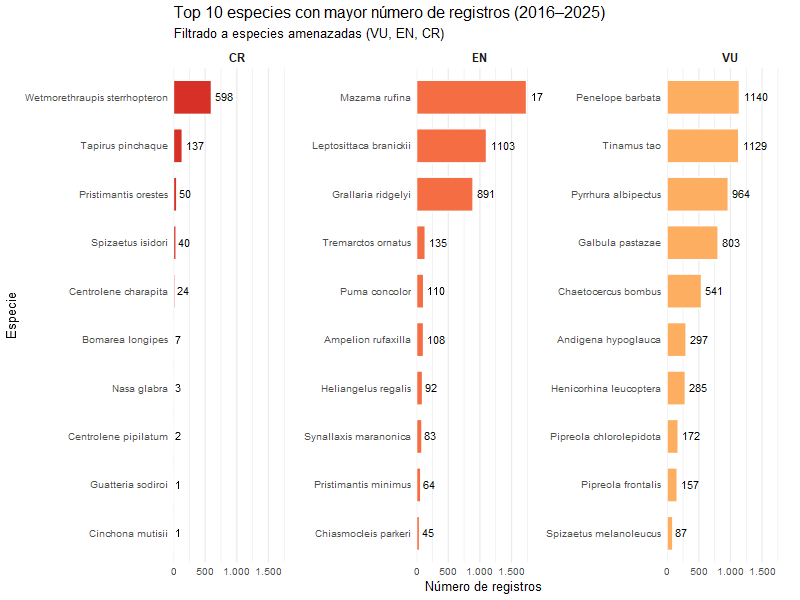

In [127]:

# =========================================================
# 1. Filtrar años y categorías de amenaza
# =========================================================
df_filtrado <- recors_zamora_ch_filter %>%
  mutate(
    year = as.numeric(year),
    Estado_conservacion = as.character(Estado_conservacion)
  ) %>%
  filter(
    year >= 2016 & year <= 2025,
    Estado_conservacion %in% c("VU", "EN", "CR"),
    !is.na(scientificName)
  )

# =========================================================
# 2. Conteo de ocurrencias por especie + categoría
# =========================================================
sp_count <- df_filtrado %>%
  group_by(scientificName, Estado_conservacion) %>%
  summarise(
    n_registros = n(),
    .groups = "drop"
  )

# =========================================================
# 3. Top 10 por categoría
# =========================================================
top_sp <- sp_count %>%
  group_by(Estado_conservacion) %>%
  slice_max(order_by = n_registros, n = 10, with_ties = FALSE) %>%
  ungroup()

# =========================================================
# 4. Orden interno por faceta
# =========================================================
top_sp <- top_sp %>%
  group_by(Estado_conservacion) %>%
  mutate(
    scientificName = reorder(scientificName, n_registros)
  ) %>%
  ungroup()

# =========================================================
# 5. Paleta consistente con riesgo
# =========================================================
pal_redlist <- c(
  "VU" = "#fdae61",
  "EN" = "#f46d43",
  "CR" = "#d73027"
)

# =========================================================
# 6. Gráfico final (facet + barras horizontales)
# =========================================================
plot_top_species <- ggplot(
  top_sp,
  aes(x = scientificName, y = n_registros, fill = Estado_conservacion)
) +
  
  geom_col(width = 0.7, color = "white") +
  
  geom_text(
    aes(label = n_registros),
    hjust = -0.2,
    size = 3.8
  ) +
  
  coord_flip() +
  
  facet_wrap(~Estado_conservacion, scales = "free_y") +
  
  scale_fill_manual(values = pal_redlist) +
  
  scale_y_continuous(
    labels = label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  
  labs(
    title = "Top 10 especies con mayor número de registros (2016–2025)",
    subtitle = "Filtrado a especies amenazadas (VU, EN, CR)",
    x = "Especie",
    y = "Número de registros"
  ) +
  
  theme_minimal(base_size = 13) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    panel.grid.major.y = element_blank(),
    legend.position = "none"
  )

plot_top_species

### Red list - Temporal assessment of threatened species

In [128]:


# =========================================================
# 1. Preparación
# =========================================================
df <- recors_zamora_ch_filter %>%
  mutate(
    eventDate = as.Date(eventDate),
    year = year(eventDate),
    month = month(eventDate)
  ) %>%
  filter(
    !is.na(scientificName),
    Estado_conservacion %in% c("VU", "EN", "CR"),
    !is.na(Group),
    !is.na(eventDate)
  )

# =========================================================
# 2. Presencia base (10 años)
# Presencia si la especie tuvo al menos un registro
# independiente en algún mes de los últimos 10 años
# =========================================================
base_10y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 9)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  distinct(scientificName, Estado_conservacion, Group) %>%
  mutate(presencia_10y = 1)

# =========================================================
# 3. Vigencia (5 años)
# Presencia si la especie tuvo al menos un registro
# independiente en algún mes de los últimos 5 años
# =========================================================
vigencia_5y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 4)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  distinct(scientificName, Estado_conservacion, Group) %>%
  mutate(presencia_5y = 1)

# =========================================================
# 4. Conteo de registros independientes por mes
# en los últimos 5 años
# Si hay 5 registros en el mismo mes-año, cuenta como 1
# =========================================================
registros_5y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 4)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  group_by(scientificName, Estado_conservacion, Group) %>%
  summarise(
    total_registros_5y = n(),
    .groups = "drop"
  )

# =========================================================
# 5. Integración
# =========================================================
estado_sp <- full_join(
  base_10y,
  vigencia_5y,
  by = c("scientificName", "Estado_conservacion", "Group")
) %>%
  mutate(
    presencia_10y = ifelse(is.na(presencia_10y), 0, presencia_10y),
    presencia_5y  = ifelse(is.na(presencia_5y), 0, presencia_5y)
  ) %>%
  left_join(
    registros_5y,
    by = c("scientificName", "Estado_conservacion", "Group")
  ) %>%
  mutate(
    total_registros_5y = ifelse(is.na(total_registros_5y), 0, total_registros_5y)
  )

# =========================================================
# 6. Clasificación diagnóstica
# =========================================================
estado_sp <- estado_sp %>%
  mutate(
    estado_diagnostico = case_when(
      presencia_10y == 1 & presencia_5y == 1 ~ "Confirmada y vigente",
      presencia_10y == 1 & presencia_5y == 0 ~ "Alerta (sin registros recientes)",
      presencia_10y == 0 ~ "Sin evidencia reciente"
    )
  )


Summary

In [129]:
# =========================================================
# 7. Resumen final (solo conteo de especies por categoría)
# =========================================================
resumen_estado <- estado_sp %>%
  group_by(Estado_conservacion, estado_diagnostico) %>%
  summarise(
    n_especies = n_distinct(scientificName),
    .groups = "drop"
  )

resumen_estado

# A tibble: 6 × 3
  Estado_conservacion estado_diagnostico               n_especies
  <chr>               <chr>                                 <int>
1 CR                  Alerta (sin registros recientes)          6
2 CR                  Confirmada y vigente                      8
3 EN                  Alerta (sin registros recientes)         37
4 EN                  Confirmada y vigente                     52
5 VU                  Alerta (sin registros recientes)         58
6 VU                  Confirmada y vigente                    115

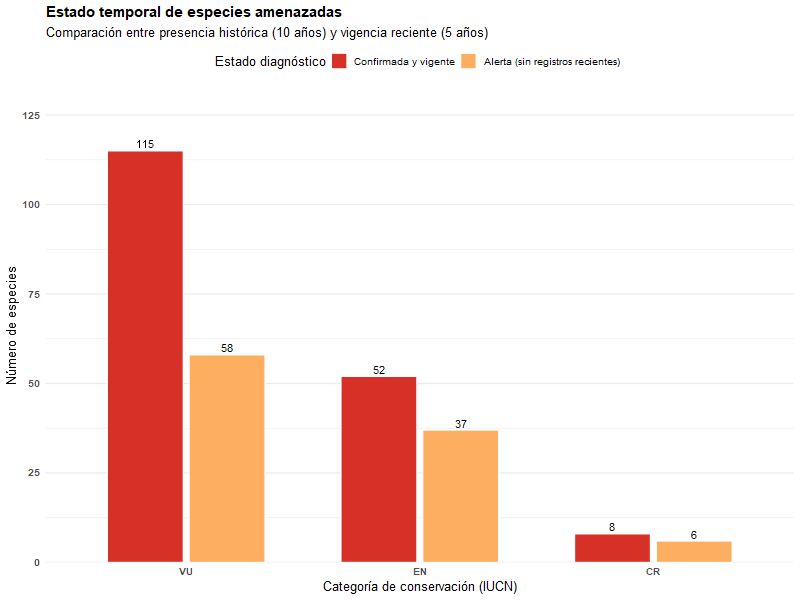

In [130]:


# =========================================================
# 1. Ordenar factores
# =========================================================
resumen_estado <- resumen_estado %>%
  mutate(
    Estado_conservacion = factor(Estado_conservacion, levels = c("VU", "EN", "CR")),
    estado_diagnostico = factor(
      estado_diagnostico,
      levels = c(
        "Confirmada y vigente",
        "Alerta (sin registros recientes)",
        "Sin evidencia reciente"
      )
    )
  )

# =========================================================
# 2. Paleta coherente con diagnóstico
# =========================================================
pal_estado <- c(
  "Confirmada y vigente" = "#d73027",   # azul (estable)
  "Alerta (sin registros recientes)" = "#fdae61",  # rojo (alerta)
  "Sin evidencia reciente" = "#bdbdbd"  # gris (incertidumbre)
)

# =========================================================
# 3. Gráfico
# =========================================================
plot_resumen_estado <- ggplot(
  resumen_estado,
  aes(x = Estado_conservacion, y = n_especies, fill = estado_diagnostico)
) +
  
  geom_col(
    position = position_dodge(width = 0.7),
    width = 0.65,
    color = "white"
  ) +
  
  geom_text(
    aes(label = n_especies),
    position = position_dodge(width = 0.7),
    vjust = -0.3,
    size = 4
  ) +
  
  scale_fill_manual(values = pal_estado) +
  
  scale_y_continuous(
    labels = label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  
  labs(
    title = "Estado temporal de especies amenazadas",
    subtitle = "Comparación entre presencia histórica (10 años) y vigencia reciente (5 años)",
    x = "Categoría de conservación (IUCN)",
    y = "Número de especies",
    fill = "Estado diagnóstico"
  ) +
  
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "top",
    axis.text = element_text(face = "bold"),
    plot.title = element_text(size = 15, face = "bold")
  )

plot_resumen_estado

## 5.2 ACUS

In [131]:
recors_acus_filter <- bio_records_complt %>%
  filter(!is.na(Nombre)) %>%
 # filter(!is.na(Nombre))%>%
  as.data.frame() %>%
  dplyr::filter(
    (kingdom == "Animalia" & class %in% c("Amphibia","Aves","Mammalia","Reptilia","Squamata")) |
    (kingdom == "Plantae")
  ) %>%
  dplyr::mutate(
    Group = dplyr::case_when(
      kingdom == "Plantae" ~ "Plantas",
      class %in% c("Reptilia","Squamata") ~ "Reptiles",
      class == "Amphibia" ~ "Anfibios",
      class == "Aves" ~ "Aves",
      class == "Mammalia" ~ "Mamíferos",
      TRUE ~ NA_character_
    )
  )

head(recors_acus_filter)

   X database_id               scientificName       occurrenceID  eventDate  kingdom   phylum    class order
1  2 BIOWEB_1256      Pristimantis nangaritza QCAZA41728_SC28166 2009-04-19 Animalia Chordata Amphibia Anura
2  6 BIOWEB_1574     Pristimantis cryptomelas QCAZA57146_SC46606 2014-04-13 Animalia Chordata Amphibia Anura
3  7 BIOWEB_1575     Pristimantis cryptomelas QCAZA57147_SC46607 2014-04-13 Animalia Chordata Amphibia Anura
4  8 BIOWEB_1601          Rulyrana mcdiarmidi QCAZA57575_SC47119 2014-07-10 Animalia Chordata Amphibia Anura
5  9 BIOWEB_1626       Pristimantis incomptus QCAZA57603_SC47148 2014-07-09 Animalia Chordata Amphibia Anura
6 10 BIOWEB_1629 Pristimantis trachyblepharis QCAZA57606_SC47198 2014-07-11 Animalia Chordata Amphibia Anura
         genus specificEpithet collectionID institutionCode collectionCode ownerInstitutionCode basisOfRecord
1 Pristimantis      nangaritza         <NA>            <NA>           <NA>                 <NA>          <NA>
2 Pristimantis   

### Records by group

In [132]:
records_by_group_acus= recors_acus_filter %>%
  group_by(Group)%>%
  summarise(Total_records = n())%>%
  arrange(-Total_records)
records_by_group_acus

# A tibble: 5 × 2
  Group     Total_records
  <chr>             <int>
1 Aves             108540
2 Plantas           31201
3 Mamíferos          2926
4 Anfibios           2089
5 Reptiles            627

In [133]:
icons_plots = c("../Icons/Aves.png", "../Icons/Plantas.png", "../Icons/mamiferos.png", "../Icons/anfibios.png", "../Icons/reptiles.png")
records_by_group_acus$Incons = icons_plots

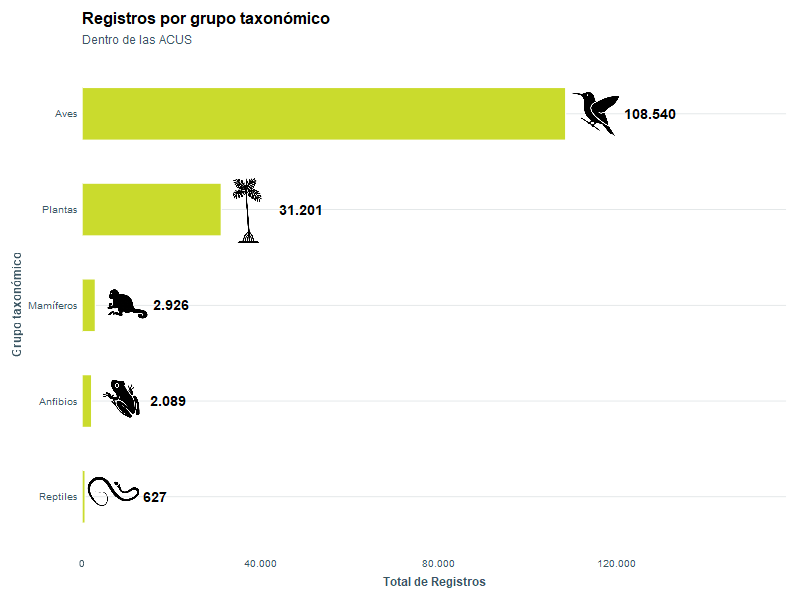

In [134]:
# 1. Calcular un margen dinámico basado en el valor máximo de tus datos
# Esto asegura que la separación sea proporcional al gráfico
max_val <- max(records_by_group_acus$Total_records, na.rm = TRUE)
offset_etiqueta <- max_val * 0.12  # 12% del máximo para el texto
offset_imagen <- max_val * 0.06    # 5% del máximo para el icono

# 2. Crear el gráfico
plot_records_group_acus<- ggplot(records_by_group_acus, aes(x = reorder(Group, Total_records), y = Total_records)) +
  # Barras
  geom_bar(stat = "identity", width = 0.55, fill = pal_zch["verde_lima"], color = "white") +
  
  # IMAGEN: Usamos posición dinámica en 'y' en lugar de nudge fijo
  geom_image(
    aes(y = Total_records + offset_imagen, image = icons_plots),
    size = 0.11, # Ajustado ligeramente para que no sature
    by = "width"
  ) +
  
  # ETIQUETAS: Posición dinámica para que siempre estén a la derecha de la imagen
  geom_text(
    aes(
      y = Total_records + offset_etiqueta, 
      label = scales::number(Total_records, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,                   # Alineado a la izquierda desde el punto de inserción
    color = "black",
    fontface = "bold",
    size = 5
  ) +
  
  coord_flip() +
  
  # ESCALA Y: Aumentamos el 'expand' para dar espacio a la derecha
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.3)) # 30% de espacio extra a la derecha
  ) +
  
  labs(
    title = "Registros por grupo taxonómico",
    x = "Grupo taxonómico",
    y = "Total de Registros",
    subtitle = "Dentro de las ACUS"
  ) +
  
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none"
  )

# Visualizar
plot_records_group_acus

In [135]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Report_ocurrences/Records_ACUS.png", 
  plot = plot_records_group_acus, 
  device = "png",
  width = 165,               # Ancho en mm
  height = 130,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### Species by group

In [136]:
sp_by_group_acus= recors_acus_filter %>%
  group_by(Group)%>%
  distinct(scientificName)%>%
  summarise(Total_sp = n())%>%
  arrange(-Total_sp)
sp_by_group_acus

# A tibble: 5 × 2
  Group     Total_sp
  <chr>        <int>
1 Plantas       4717
2 Aves           836
3 Anfibios       139
4 Mamíferos       99
5 Reptiles        70

In [137]:
icons_plots = c("../Icons/Plantas.png", "../Icons/Aves.png", "../Icons/anfibios.png", "../Icons/mamiferos.png", "../Icons/reptiles.png")
sp_by_group_acus$Incons = icons_plots

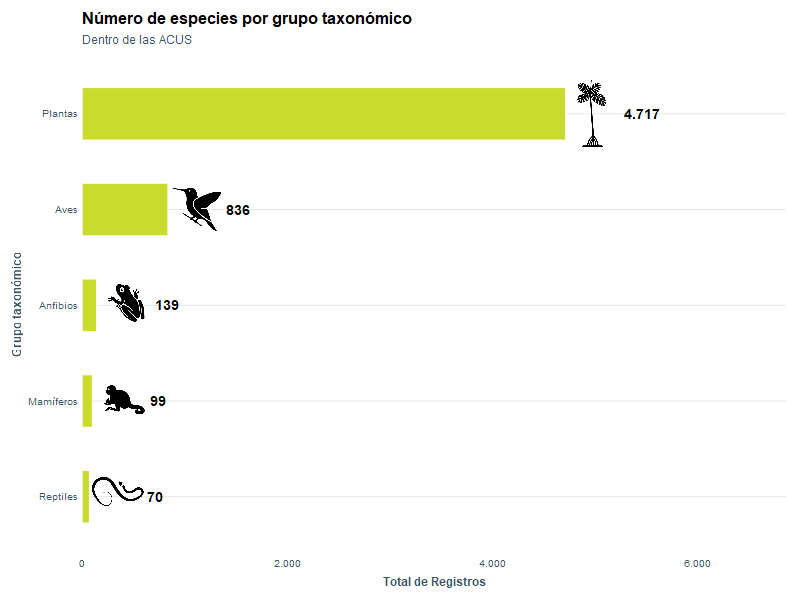

In [138]:
# 1. Calcular un margen dinámico basado en el valor máximo de tus datos
# Esto asegura que la separación sea proporcional al gráfico
max_val <- max(sp_by_group_acus$Total_sp, na.rm = TRUE)
offset_etiqueta <- max_val * 0.12  # 12% del máximo para el texto
offset_imagen <- max_val * 0.06    # 5% del máximo para el icono

# 2. Crear el gráfico
plot_sp_group_acus<- ggplot(sp_by_group_acus, aes(x = reorder(Group, Total_sp), y = Total_sp)) +
  # Barras
  geom_bar(stat = "identity", width = 0.55, fill = pal_zch["verde_lima"], color = "white") +
  
  # IMAGEN: Usamos posición dinámica en 'y' en lugar de nudge fijo
  geom_image(
    aes(y = Total_sp + offset_imagen, image = icons_plots),
    size = 0.11, # Ajustado ligeramente para que no sature
    by = "width"
  ) +
  
  # ETIQUETAS: Posición dinámica para que siempre estén a la derecha de la imagen
  geom_text(
    aes(
      y = Total_sp + offset_etiqueta, 
      label = scales::number(Total_sp, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,                   # Alineado a la izquierda desde el punto de inserción
    color = "black",
    fontface = "bold",
    size = 5
  ) +
  
  coord_flip() +
  
  # ESCALA Y: Aumentamos el 'expand' para dar espacio a la derecha
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.3)) # 30% de espacio extra a la derecha
  ) +
  
  labs(
    title = "Número de especies por grupo taxonómico",
    x = "Grupo taxonómico",
    y = "Total de Registros",
    subtitle = "Dentro de las ACUS"
  ) +
  
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none"
  )

# Visualizar
plot_sp_group_acus

In [139]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Report_ocurrences/Sp_ACUS.png", 
  plot = plot_sp_group_acus, 
  device = "png",
  width = 165,               # Ancho en mm
  height = 130,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### Red list

In [140]:
sp_by_group_redlist_acus = recors_acus_filter %>%
  #filter(!is.na(Estado_conservacion))%>%
  filter(Estado_conservacion %in% c("VU" ,"EN" , "CR"))%>%
  group_by(Group,Estado_conservacion)%>%
  distinct(scientificName)%>%
  summarise(Total_sp = n())
sp_by_group_redlist_acus

`summarise()` has grouped output by 'Group'. You can override using the `.groups` argument.


# A tibble: 14 × 3
# Groups:   Group [5]
   Group     Estado_conservacion Total_sp
   <chr>     <chr>                  <int>
 1 Anfibios  CR                         5
 2 Anfibios  EN                        22
 3 Anfibios  VU                        24
 4 Aves      CR                         2
 5 Aves      EN                        12
 6 Aves      VU                        22
 7 Mamíferos CR                         1
 8 Mamíferos EN                         6
 9 Mamíferos VU                        10
10 Plantas   CR                        20
11 Plantas   EN                        93
12 Plantas   VU                       254
13 Reptiles  EN                         2
14 Reptiles  VU                         1

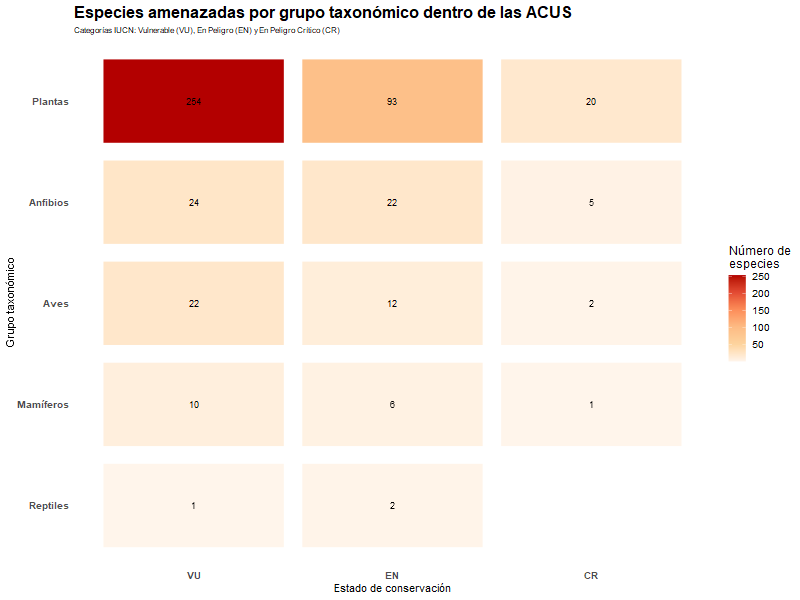

In [141]:


# =========================================================
# 1. Ordenar grupos por total de especies amenazadas
# =========================================================
orden_grupos <- sp_by_group_redlist_acus %>%
  group_by(Group) %>%
  summarise(total = sum(Total_sp), .groups = "drop") %>%
  arrange(total) %>%
  pull(Group)

sp_plot <- sp_by_group_redlist_acus %>%
  mutate(
    Group = factor(Group, levels = orden_grupos),
    Estado_conservacion = factor(
      Estado_conservacion,
      levels = c("VU", "EN", "CR")
    )
  )

# =========================================================
# 2. Heatmap con escala rojo-naranja
# =========================================================
plot_redlist_heatmap_acus <- ggplot(
  sp_plot,
  aes(x = Estado_conservacion, y = Group, fill = Total_sp)
) +
  geom_tile(
    color = "white",
    linewidth = 1.2,
    width = 0.92,
    height = 0.85
  ) +
  geom_text(
    aes(label = number(Total_sp, big.mark = ".", decimal.mark = ",")),
    color = "black",
    size = 3
  ) +
  scale_fill_gradientn(
    colours = c("#fff5eb", "#fdd49e", "#fdbb84", "#fc8d59", "#e34a33", "#b30000"),
    labels = label_number(big.mark = ".", decimal.mark = ",")
  ) +
  labs(
    title = "Especies amenazadas por grupo taxonómico dentro de las ACUS",
    subtitle = "Categorías IUCN: Vulnerable (VU), En Peligro (EN) y En Peligro Crítico (CR)",
    x = "Estado de conservación",
    y = "Grupo taxonómico",
    fill = "Número de\nespecies"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.title.x = element_text(size = 11),
    axis.title.y = element_text(size = 11),
    axis.text.x = element_text(size = 10, face = "bold"),
    axis.text.y = element_text(size = 10, face = "bold"),
    legend.position = "right",
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 8)
  )

  plot_redlist_heatmap_acus

In [142]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Report_ocurrences/Red_list_ACUS.png", 
  plot = plot_redlist_heatmap_acus, 
  device = "png",
  width = 185,               # Ancho en mm
  height = 130,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### Red list - last 10 years

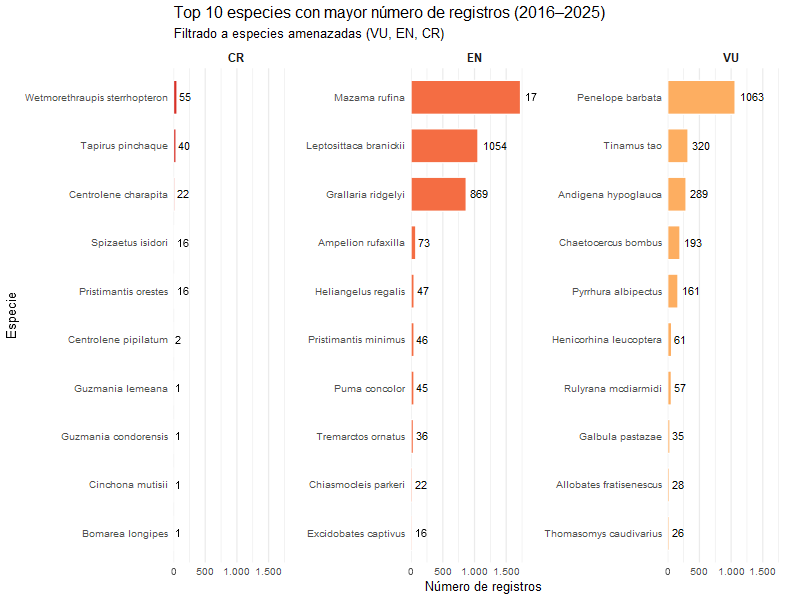

In [143]:

# =========================================================
# 1. Filtrar años y categorías de amenaza
# =========================================================
df_filtrado <- recors_acus_filter %>%
  mutate(
    year = as.numeric(year),
    Estado_conservacion = as.character(Estado_conservacion)
  ) %>%
  filter(
    year >= 2016 & year <= 2025,
    Estado_conservacion %in% c("VU", "EN", "CR"),
    !is.na(scientificName)
  )

# =========================================================
# 2. Conteo de ocurrencias por especie + categoría
# =========================================================
sp_count <- df_filtrado %>%
  group_by(scientificName, Estado_conservacion) %>%
  summarise(
    n_registros = n(),
    .groups = "drop"
  )

# =========================================================
# 3. Top 10 por categoría
# =========================================================
top_sp <- sp_count %>%
  group_by(Estado_conservacion) %>%
  slice_max(order_by = n_registros, n = 10, with_ties = FALSE) %>%
  ungroup()

# =========================================================
# 4. Orden interno por faceta
# =========================================================
top_sp <- top_sp %>%
  group_by(Estado_conservacion) %>%
  mutate(
    scientificName = reorder(scientificName, n_registros)
  ) %>%
  ungroup()

# =========================================================
# 5. Paleta consistente con riesgo
# =========================================================
pal_redlist <- c(
  "VU" = "#fdae61",
  "EN" = "#f46d43",
  "CR" = "#d73027"
)

# =========================================================
# 6. Gráfico final (facet + barras horizontales)
# =========================================================
plot_top_species_acus <- ggplot(
  top_sp,
  aes(x = scientificName, y = n_registros, fill = Estado_conservacion)
) +
  
  geom_col(width = 0.7, color = "white") +
  
  geom_text(
    aes(label = n_registros),
    hjust = -0.2,
    size = 3.8
  ) +
  
  coord_flip() +
  
  facet_wrap(~Estado_conservacion, scales = "free_y") +
  
  scale_fill_manual(values = pal_redlist) +
  
  scale_y_continuous(
    labels = label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  
  labs(
    title = "Top 10 especies con mayor número de registros (2016–2025)",
    subtitle = "Filtrado a especies amenazadas (VU, EN, CR)",
    x = "Especie",
    y = "Número de registros"
  ) +
  
  theme_minimal(base_size = 13) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    panel.grid.major.y = element_blank(),
    legend.position = "none"
  )

  plot_top_species_acus

### Red list - Temporal assessment of threatened species

In [144]:


# =========================================================
# 1. Preparación
# =========================================================
df <- recors_acus_filter %>%
  mutate(
    eventDate = as.Date(eventDate),
    year = year(eventDate),
    month = month(eventDate)
  ) %>%
  filter(
    !is.na(scientificName),
    Estado_conservacion %in% c("VU", "EN", "CR"),
    !is.na(Group),
    !is.na(eventDate)
  )

# =========================================================
# 2. Presencia base (10 años)
# Presencia si la especie tuvo al menos un registro
# independiente en algún mes de los últimos 10 años
# =========================================================
base_10y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 9)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  distinct(scientificName, Estado_conservacion, Group) %>%
  mutate(presencia_10y = 1)

# =========================================================
# 3. Vigencia (5 años)
# Presencia si la especie tuvo al menos un registro
# independiente en algún mes de los últimos 5 años
# =========================================================
vigencia_5y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 4)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  distinct(scientificName, Estado_conservacion, Group) %>%
  mutate(presencia_5y = 1)

# =========================================================
# 4. Conteo de registros independientes por mes
# en los últimos 5 años
# Si hay 5 registros en el mismo mes-año, cuenta como 1
# =========================================================
registros_5y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 4)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  group_by(scientificName, Estado_conservacion, Group) %>%
  summarise(
    total_registros_5y = n(),
    .groups = "drop"
  )

# =========================================================
# 5. Integración
# =========================================================
estado_sp <- full_join(
  base_10y,
  vigencia_5y,
  by = c("scientificName", "Estado_conservacion", "Group")
) %>%
  mutate(
    presencia_10y = ifelse(is.na(presencia_10y), 0, presencia_10y),
    presencia_5y  = ifelse(is.na(presencia_5y), 0, presencia_5y)
  ) %>%
  left_join(
    registros_5y,
    by = c("scientificName", "Estado_conservacion", "Group")
  ) %>%
  mutate(
    total_registros_5y = ifelse(is.na(total_registros_5y), 0, total_registros_5y)
  )

# =========================================================
# 6. Clasificación diagnóstica
# =========================================================
estado_sp <- estado_sp %>%
  mutate(
    estado_diagnostico = case_when(
      presencia_10y == 1 & presencia_5y == 1 ~ "Confirmada y vigente",
      presencia_10y == 1 & presencia_5y == 0 ~ "Alerta (sin registros recientes)",
      presencia_10y == 0 ~ "Sin evidencia reciente"
    )
  )

Summary

In [145]:
# =========================================================
# 7. Resumen final (solo conteo de especies por categoría)
# =========================================================
resumen_estado <- estado_sp %>%
  group_by(Estado_conservacion, estado_diagnostico) %>%
  summarise(
    n_especies = n_distinct(scientificName),
    .groups = "drop"
  )

resumen_estado

# A tibble: 6 × 3
  Estado_conservacion estado_diagnostico               n_especies
  <chr>               <chr>                                 <int>
1 CR                  Alerta (sin registros recientes)          6
2 CR                  Confirmada y vigente                      6
3 EN                  Alerta (sin registros recientes)         24
4 EN                  Confirmada y vigente                     29
5 VU                  Alerta (sin registros recientes)         33
6 VU                  Confirmada y vigente                     65

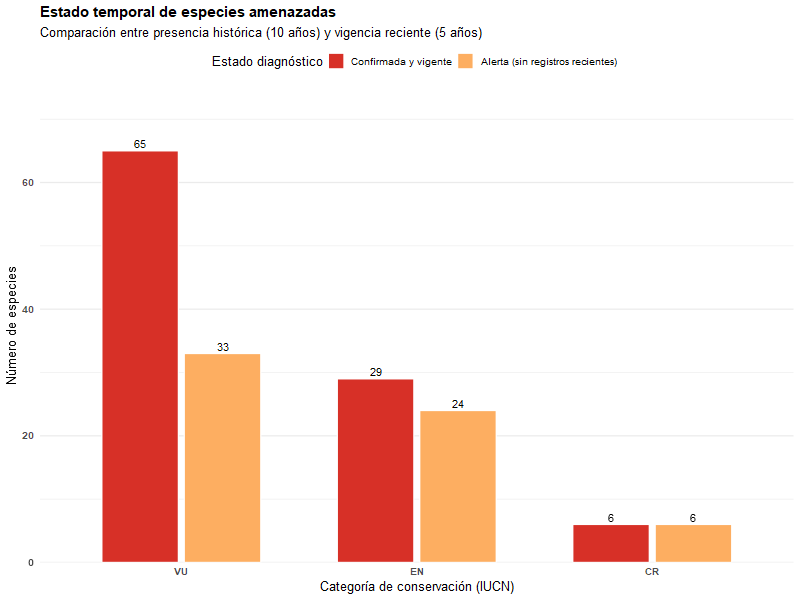

In [146]:


# =========================================================
# 1. Ordenar factores
# =========================================================
resumen_estado <- resumen_estado %>%
  mutate(
    Estado_conservacion = factor(Estado_conservacion, levels = c("VU", "EN", "CR")),
    estado_diagnostico = factor(
      estado_diagnostico,
      levels = c(
        "Confirmada y vigente",
        "Alerta (sin registros recientes)",
        "Sin evidencia reciente"
      )
    )
  )

# =========================================================
# 2. Paleta coherente con diagnóstico
# =========================================================
pal_estado <- c(
  "Confirmada y vigente" = "#d73027",   # azul (estable)
  "Alerta (sin registros recientes)" = "#fdae61",  # rojo (alerta)
  "Sin evidencia reciente" = "#bdbdbd"  # gris (incertidumbre)
)

# =========================================================
# 3. Gráfico
# =========================================================
plot_resumen_estado_acus <- ggplot(
  resumen_estado,
  aes(x = Estado_conservacion, y = n_especies, fill = estado_diagnostico)
) +
  
  geom_col(
    position = position_dodge(width = 0.7),
    width = 0.65,
    color = "white"
  ) +
  
  geom_text(
    aes(label = n_especies),
    position = position_dodge(width = 0.7),
    vjust = -0.3,
    size = 4
  ) +
  
  scale_fill_manual(values = pal_estado) +
  
  scale_y_continuous(
    labels = label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  
  labs(
    title = "Estado temporal de especies amenazadas",
    subtitle = "Comparación entre presencia histórica (10 años) y vigencia reciente (5 años)",
    x = "Categoría de conservación (IUCN)",
    y = "Número de especies",
    fill = "Estado diagnóstico"
  ) +
  
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "top",
    axis.text = element_text(face = "bold"),
    plot.title = element_text(size = 15, face = "bold")
  )

  plot_resumen_estado_acus

## 5.3. By each ACUS

### Records by acus - group

In [147]:
records_by_group_acus= recors_acus_filter %>%
  group_by(Nombre,Group)%>%
  summarise(Total_records = n())%>%
  arrange(-Total_records)
records_by_group_acus

`summarise()` has grouped output by 'Nombre'. You can override using the `.groups` argument.


# A tibble: 20 × 3
# Groups:   Nombre [4]
   Nombre                Group     Total_records
   <chr>                 <chr>             <int>
 1 Bracamoros            Aves              80124
 2 Cordillera del Condor Aves              16867
 3 Yawi Sumak            Plantas           13132
 4 Cordillera del Condor Plantas           11168
 5 Fuentes de agua       Aves               6636
 6 Bracamoros            Plantas            6496
 7 Yawi Sumak            Aves               4913
 8 Cordillera del Condor Mamíferos          2141
 9 Cordillera del Condor Anfibios           1417
10 Bracamoros            Mamíferos           571
11 Bracamoros            Anfibios            411
12 Fuentes de agua       Plantas             405
13 Cordillera del Condor Reptiles            319
14 Yawi Sumak            Reptiles            231
15 Yawi Sumak            Mamíferos           213
16 Yawi Sumak            Anfibios            201
17 Fuentes de agua       Anfibios             60
18 Bracamoros            Re

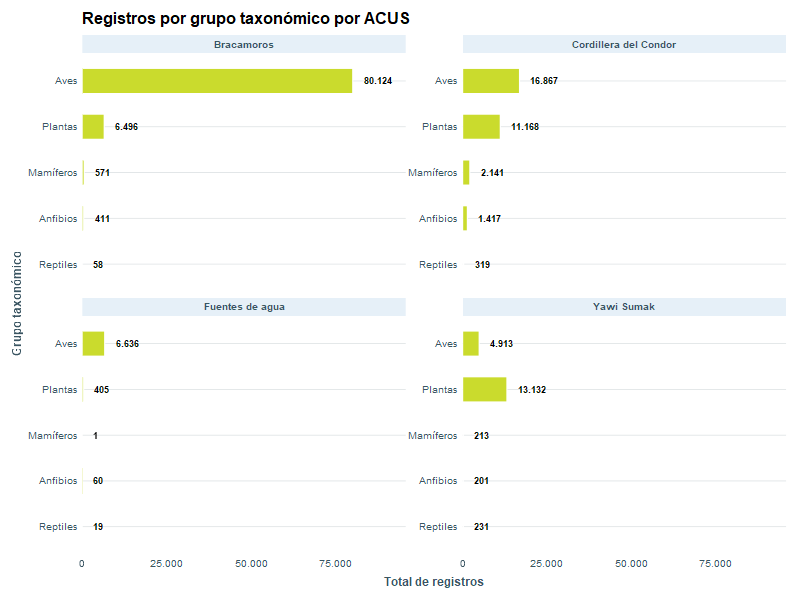

In [148]:
max_val <- max(records_by_group_acus$Total_records, na.rm = TRUE)
offset_etiqueta <- max_val * 0.04

plot_records_group_acus_2 <- ggplot(
  records_by_group_acus,
  aes(x = reorder(Group, Total_records), y = Total_records)
) +
  geom_bar(
    stat = "identity",
    width = 0.55,
    fill = pal_zch["verde_lima"],
    color = "white"
  ) +
  geom_text(
    aes(
      y = Total_records + offset_etiqueta,
      label = scales::number(Total_records, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,
    color = "black",
    fontface = "bold",
    size = 3
  ) +
  coord_flip() +
  facet_wrap(~Nombre, scales = "free_y") +
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  labs(
    title = "Registros por grupo taxonómico por ACUS",
    x = "Grupo taxonómico",
    y = "Total de registros"
  ) +
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none",
    strip.text = element_text(face = "bold")
  )

plot_records_group_acus_2

In [149]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Report_ocurrences/Records_BY_ACUS.png", 
  plot = plot_records_group_acus_2, 
  device = "png",
  width = 195,               # Ancho en mm
  height = 170,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### Species by group

In [150]:
sp_by_group_acus= recors_acus_filter %>%
  group_by(Nombre, Group)%>%
  distinct(scientificName)%>%
  summarise(Total_sp = n())%>%
  arrange(-Total_sp)
sp_by_group_acus

`summarise()` has grouped output by 'Nombre'. You can override using the `.groups` argument.


# A tibble: 20 × 3
# Groups:   Nombre [4]
   Nombre                Group     Total_sp
   <chr>                 <chr>        <int>
 1 Yawi Sumak            Plantas       2834
 2 Cordillera del Condor Plantas       1982
 3 Bracamoros            Plantas       1326
 4 Cordillera del Condor Aves           611
 5 Bracamoros            Aves           553
 6 Yawi Sumak            Aves           419
 7 Fuentes de agua       Aves           326
 8 Fuentes de agua       Plantas        201
 9 Cordillera del Condor Anfibios       107
10 Cordillera del Condor Mamíferos       63
11 Cordillera del Condor Reptiles        46
12 Yawi Sumak            Anfibios        40
13 Bracamoros            Anfibios        38
14 Yawi Sumak            Mamíferos       38
15 Bracamoros            Mamíferos       31
16 Yawi Sumak            Reptiles        27
17 Bracamoros            Reptiles        17
18 Fuentes de agua       Anfibios        14
19 Fuentes de agua       Reptiles         6
20 Fuentes de agua       Mamíferos

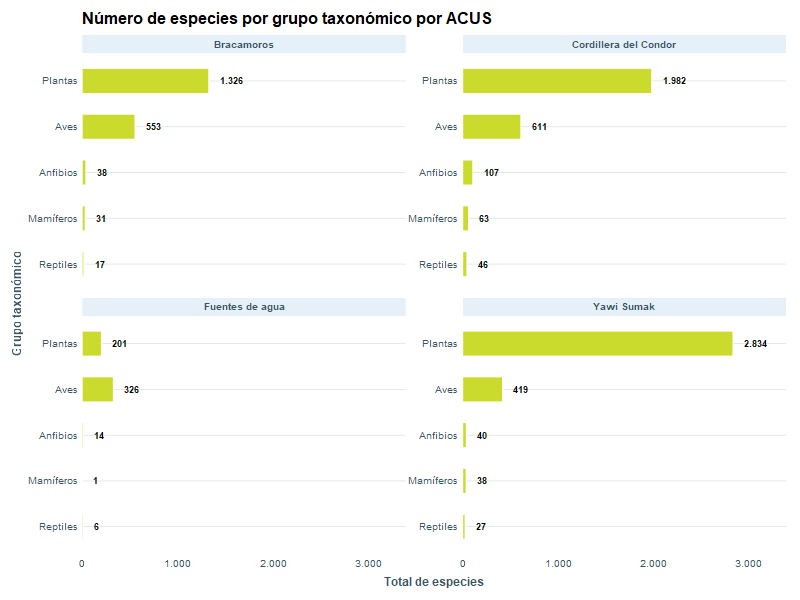

In [161]:
max_val <- max(sp_by_group_acus$Total_sp, na.rm = TRUE)
offset_etiqueta <- max_val * 0.04

plot_sp_group_acus_2 <- ggplot(
  sp_by_group_acus,
  aes(x = reorder(Group, Total_sp), y = Total_sp)
) +
  geom_bar(
    stat = "identity",
    width = 0.55,
    fill = pal_zch["verde_lima"],
    color = "white"
  ) +
  geom_text(
    aes(
      y = Total_sp + offset_etiqueta,
      label = scales::number(Total_sp, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,
    color = "black",
    fontface = "bold",
    size = 3
  ) +
  coord_flip() +
  facet_wrap(~Nombre, scales = "free_y") +
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  labs(
    title = "Número de especies por grupo taxonómico por ACUS",
    x = "Grupo taxonómico",
    y = "Total de especies"
  ) +
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none",
    strip.text = element_text(face = "bold")
  )

plot_sp_group_acus_2

In [162]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Report_ocurrences/SP_BY_ACUS.png", 
  plot = plot_sp_group_acus_2, 
  device = "png",
  width = 215,               # Ancho en mm
  height = 170,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### Red list

In [153]:
sp_by_group_redlist_acus <- recors_acus_filter %>%
  filter(Estado_conservacion %in% c("VU", "EN", "CR")) %>%
  distinct(Nombre, Group, Estado_conservacion, scientificName) %>%
  count(Nombre, Group, Estado_conservacion, name = "Total_sp")
sp_by_group_redlist_acus

                  Nombre     Group Estado_conservacion Total_sp
1             Bracamoros  Anfibios                  CR        1
2             Bracamoros  Anfibios                  EN        9
3             Bracamoros  Anfibios                  VU       11
4             Bracamoros      Aves                  CR        1
5             Bracamoros      Aves                  EN        7
6             Bracamoros      Aves                  VU       15
7             Bracamoros Mamíferos                  CR        1
8             Bracamoros Mamíferos                  EN        1
9             Bracamoros Mamíferos                  VU        6
10            Bracamoros   Plantas                  CR        6
11            Bracamoros   Plantas                  EN       25
12            Bracamoros   Plantas                  VU       87
13 Cordillera del Condor  Anfibios                  CR        4
14 Cordillera del Condor  Anfibios                  EN       11
15 Cordillera del Condor  Anfibios      

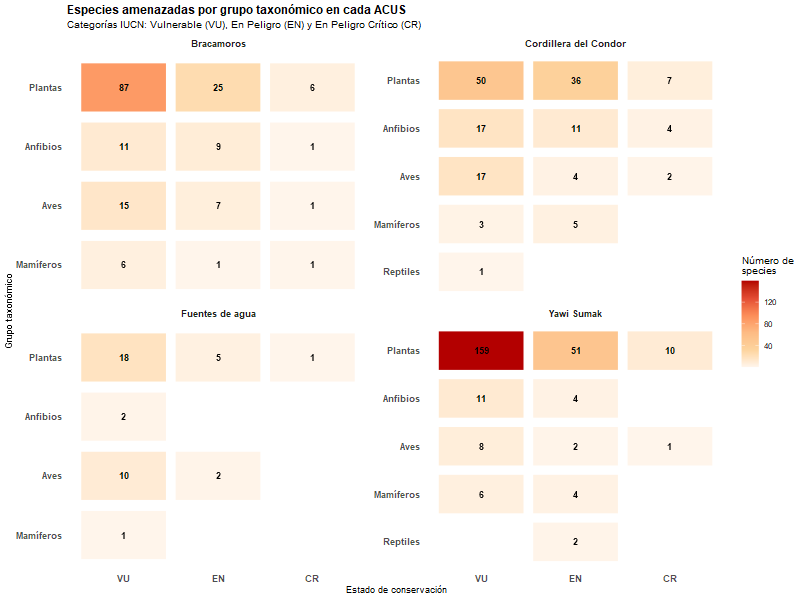

In [154]:

# =========================================================
# 1. Preparar datos
# =========================================================
sp_plot_redlist_acus <- sp_by_group_redlist_acus %>%
  ungroup() %>%
  mutate(
    Estado_conservacion = factor(
      Estado_conservacion,
      levels = c("VU", "EN", "CR")
    )
  ) %>%
  group_by(Group) %>%
  mutate(total_group = sum(Total_sp, na.rm = TRUE)) %>%
  ungroup() %>%
  mutate(
    Group = reorder(Group, total_group)
  )

# =========================================================
# 2. Gráfica
# =========================================================
plot_redlist_acus_2 <- ggplot(
  sp_plot_redlist_acus,
  aes(x = Estado_conservacion, y = Group, fill = Total_sp)
) +
  geom_tile(
    color = "white",
    linewidth = 1,
    width = 0.92,
    height = 0.85
  ) +
  geom_text(
    aes(label = number(Total_sp, big.mark = ".", decimal.mark = ",")),
    color = "black",
    size = 3,
    fontface = "bold"
  ) +
  facet_wrap(~Nombre, scales = "free_y") +
  scale_fill_gradientn(
    colours = c("#fff5eb", "#fdd49e", "#fdbb84", "#fc8d59", "#e34a33", "#b30000"),
    labels = label_number(big.mark = ".", decimal.mark = ","),
    name = "Número de\nspecies"
  ) +
  labs(
    title = "Especies amenazadas por grupo taxonómico en cada ACUS",
    subtitle = "Categorías IUCN: Vulnerable (VU), En Peligro (EN) y En Peligro Crítico (CR)",
    x = "Estado de conservación",
    y = "Grupo taxonómico"
  ) +
  theme_minimal(base_size = 10) +
  theme(
    panel.grid = element_blank(),
    axis.title.x = element_text(size = 9),
    axis.title.y = element_text(size = 9),
    axis.text.x = element_text(size = 9, face = "bold"),
    axis.text.y = element_text(size = 9, face = "bold"),
    strip.text = element_text(size = 9, face = "bold"),
    plot.title = element_text(size = 12, face = "bold"),
    plot.subtitle = element_text(size = 10),
    legend.position = "right"
  )

plot_redlist_acus_2

In [155]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Report_ocurrences/REDLIST_BY_ACUS.png", 
  plot = plot_redlist_acus_2, 
  device = "png",
  width = 195,               # Ancho en mm
  height = 170,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### Representation of the province

--- RESUMEN DE BIODIVERSIDAD ---
Total especies en la provincia: 8889 
Total especies capturadas por las ACUS: 5859 ( 65.91 %)
Especies cuya presencia es EXCLUSIVA de las ACUS: 1914 

# A tibble: 4 × 4
  Nombre                Riqueza_Total Especies_Exclusivas_Area Representatividad_Provincial
  <chr>                         <int>                    <int>                        <dbl>
1 Bracamoros                     1965                      461                        22.1 
2 Cordillera del Condor          2809                      567                        31.6 
3 Fuentes de agua                 548                       52                         6.16
4 Yawi Sumak                     3358                     1056                        37.8 


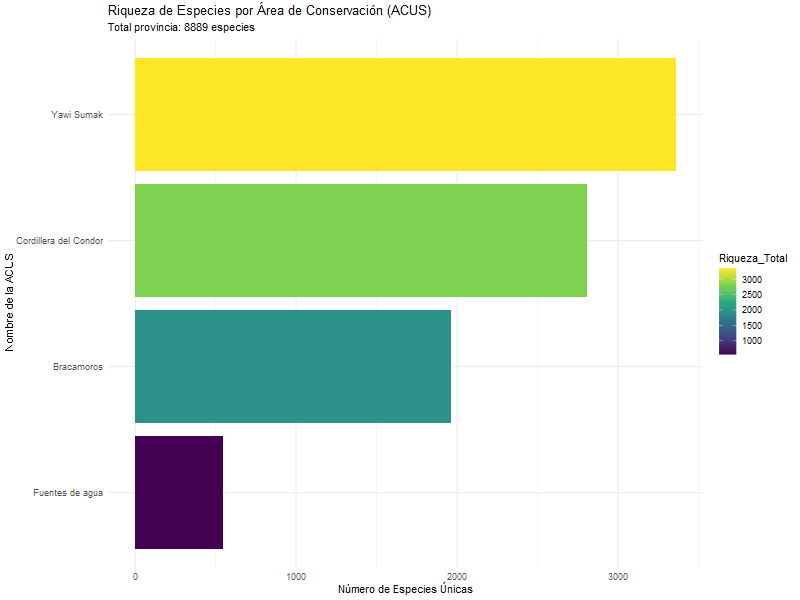

In [156]:


# 1. Definir los pools de especies (Identidades únicas)
pool_provincia <- recors_zamora_ch_filter %>% 
  pull(scientificName) %>% 
  unique()

pool_total_acus <- recors_acus_filter %>% 
  pull(scientificName) %>% 
  unique()

# 2. Análisis Global: ¿Cuántas del total están en las ACUS?
n_total <- length(pool_provincia)
n_en_acus <- sum(pool_total_acus %in% pool_provincia)
porcentaje_protegido <- (n_en_acus / n_total) * 100

# 3. Especies EXCLUSIVAS (Solo registradas dentro de ACUS)
# Esto identifica especies que NO aparecen en el dataset general de la provincia 
# (fuera de las áreas protegidas)
especies_solo_acus <- setdiff(pool_total_acus, 
                              recors_zamora_ch_filter %>% 
                                filter(is.na(Nombre) | Nombre == "") %>% 
                                pull(scientificName) %>% 
                                unique())

# 4. Análisis por NOMBRE de cada ACUS
analisis_por_area <- recors_acus_filter %>%
  group_by(Nombre) %>%
  summarise(
    Riqueza_Total = n_distinct(scientificName),
    # Especies que solo están en esa ACUS específica y en ninguna otra parte de la provincia
    Especies_Exclusivas_Area = sum(!(unique(scientificName) %in% 
                                     (recors_zamora_ch_filter %>% 
                                      filter(Nombre != first(Nombre) | is.na(Nombre)) %>% 
                                      pull(scientificName)))),
    .groups = 'drop'
  ) %>%
  mutate(Representatividad_Provincial = (Riqueza_Total / n_total) * 100)

# --- RESULTADOS EN CONSOLA ---
cat("--- RESUMEN DE BIODIVERSIDAD ---\n")
cat("Total especies en la provincia:", n_total, "\n")
cat("Total especies capturadas por las ACUS:", n_en_acus, "(", round(porcentaje_protegido, 2), "%)\n")
cat("Especies cuya presencia es EXCLUSIVA de las ACUS:", length(especies_solo_acus), "\n\n")

print(analisis_por_area)

# --- VISUALIZACIÓN ---

# Gráfico de barras por Área de Conservación
ggplot(analisis_por_area, aes(x = reorder(Nombre, Riqueza_Total), y = Riqueza_Total, fill = Riqueza_Total)) +
  geom_col() +
  coord_flip() +
  labs(title = "Riqueza de Especies por Área de Conservación (ACUS)",
       subtitle = paste("Total provincia:", n_total, "especies"),
       x = "Nombre de la ACUS",
       y = "Número de Especies Únicas") +
  theme_minimal() +
  scale_fill_viridis_c()

In [163]:

# ===============================
# Valores base
# ===============================
n_total       <- 8889
n_en_acus     <- 5859
n_exclusivas  <- 1914

# ===============================
# Radios (proporcionales al área)
# ===============================
r_total_val <- sqrt(n_total / pi)
r_acus_val  <- sqrt(n_en_acus / pi)
r_excl_val  <- sqrt(n_exclusivas / pi)

# ===============================
# Dataset final
# ===============================
datos <- tibble(
  categoria = c(
    "Total provincia",
    "En ACUS",
    "Exclusivas de ACUS"
  ),
  valor = c(n_total, n_en_acus, n_exclusivas),
  r = c(r_total_val, r_acus_val, r_excl_val),
  x0 = c(
    0,
    r_total_val - r_acus_val,
    r_total_val - r_excl_val
  ),
  y0 = c(0, 0, 0)
) %>%
  mutate(
    porcentaje = valor / n_total,
    valor_fmt = number(valor, big.mark = ".", decimal.mark = ","),
    pct_fmt = paste0(
      format(round(porcentaje * 100, 1),
             nsmall = 1,
             decimal.mark = ","),
      "%"
    ),
    etiqueta_valor = paste0(valor_fmt, " spp."),
    etiqueta_pct   = paste0("(", pct_fmt, ")")
  )

datos

# A tibble: 3 × 10
  categoria          valor     r    x0    y0 porcentaje valor_fmt pct_fmt  etiqueta_valor etiqueta_pct
  <chr>              <dbl> <dbl> <dbl> <dbl>      <dbl> <chr>     <chr>    <chr>          <chr>       
1 Total provincia     8889  53.2   0       0      1     8.889     "100,0%" 8.889 spp.     (100,0%)    
2 En ACUS             5859  43.2  10.0     0      0.659 5.859     " 65,9%" 5.859 spp.     ( 65,9%)    
3 Exclusivas de ACUS  1914  24.7  28.5     0      0.215 1.914     " 21,5%" 1.914 spp.     ( 21,5%)    

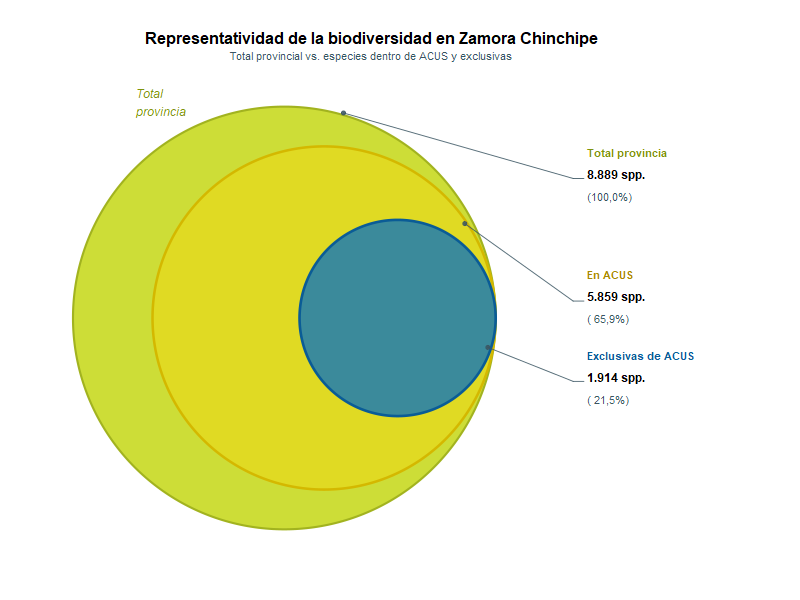

In [176]:

# Radio del círculo mayor desde el dataset
r_total_val <- datos$r[1]

# Colores
col_total_fill  <- alpha(pal_zch["verde_lima"], 0.95)
col_total_borde <- "#A2B31F"
col_acus_fill   <- alpha(pal_zch["amarillo_energia"], 0.38)
col_acus_borde  <- "#D4B800"
col_excl_fill   <- alpha(pal_zch["azul_institucional"], 0.78)
col_excl_borde  <- "#0A5C96"

col_text_main <- "black"
col_text_sec  <- pal_zch["azul_gris_tecnico"]
col_line      <- alpha(pal_zch["azul_gris_tecnico"], 0.85)

# Etiquetas y anclajes manuales
labels <- datos %>%
  mutate(
    x_text = r_total_val + 23,
    y_text = c(
      r_total_val * 0.66,   # Total provincia
      r_total_val * 0.08,   # ACUS
      -r_total_val * 0.30   # Exclusivas
    ),
    x_mid = x_text - 3.5,
    col_cat = c("#7F930F", "#A98900", "#0A5C96"),

    # Anclajes manuales según tu corrección visual
    x_ini = c(
      x0[1] + r[1] * 0.28,  # círculo grande, parte superior
      x0[2] + r[2] * 0.82,  # círculo amarillo, superior-media derecha
      x0[3] + r[3] * 0.92   # círculo azul, costado derecho
    ),
    y_ini = c(
      y0[1] + r[1] * 0.97,
      y0[2] + r[2] * 0.55,
      y0[3] - r[3] * 0.30
    )
  )

plot_final_representative <- ggplot() +
  geom_circle(
    data = datos[1,],
    aes(x0 = x0, y0 = y0, r = r),
    fill = col_total_fill, color = col_total_borde, linewidth = 1
  ) +
  geom_circle(
    data = datos[2,],
    aes(x0 = x0, y0 = y0, r = r),
    fill = col_acus_fill, color = col_acus_borde, linewidth = 1.2
  ) +
  geom_circle(
    data = datos[3,],
    aes(x0 = x0, y0 = y0, r = r),
    fill = col_excl_fill, color = col_excl_borde, linewidth = 1.25
  ) +
  geom_segment(
    data = labels,
    aes(x = x_ini, y = y_ini, xend = x_mid, yend = y_text),
    color = col_line, linewidth = 0.45, lineend = "round"
  ) +
  geom_segment(
    data = labels,
    aes(x = x_mid, y = y_text, xend = x_text - 0.8, yend = y_text),
    color = col_line, linewidth = 0.45, lineend = "round"
  ) +
  geom_point(
    data = labels,
    aes(x = x_ini, y = y_ini),
    color = col_line, size = 1.7
  ) +
  geom_text(
    data = labels,
    aes(x = x_text, y = y_text + 6.5, label = categoria),
    hjust = 0, size = 4.0, fontface = "bold", color = labels$col_cat
  ) +
  geom_text(
    data = labels,
    aes(x = x_text, y = y_text + 1.1, label = etiqueta_valor),
    hjust = 0, size = 4.3, fontface = "bold", color = col_text_main
  ) +
  geom_text(
    data = labels,
    aes(x = x_text, y = y_text - 4.6, label = etiqueta_pct),
    hjust = 0, size =4, color = col_text_sec
  ) +
  annotate(
    "text",
    x = -r_total_val * 0.70,
    y = r_total_val * 1.02,
    label = "Total\nprovincia",
    hjust = 0,
    size = 4.2,
    fontface = "italic",
    color = "#7F930F"
  ) +
  coord_fixed(
    xlim = c(-r_total_val * 1.10, max(labels$x_text) + 26),
    ylim = c(-r_total_val * 1.10, r_total_val * 1.10),
    clip = "off"
  ) +
  labs(
    title = "Representatividad de la biodiversidad en Zamora Chinchipe",
    subtitle = "Total provincial vs. especies dentro de ACUS y exclusivas"
  ) +
  theme_void() +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    panel.background = element_rect(fill = "white", color = NA),
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
    plot.subtitle = element_text(color = pal_zch["azul_gris_tecnico"], hjust = 0.5),
    plot.margin = margin(20, 78, 20, 20),
    legend.position = "none"
  )

print(plot_final_representative)

In [177]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Report_ocurrences/Distribution_sp_province_acus.png", 
  plot = plot_final_representative, 
  device = "png",
  width = 200,               # Ancho en mm
  height = 150,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)